# Vehicle Part Segmentation with YOLOv11

An end-to-end, **idempotent** pipeline for instance segmentation of car parts using **Ultralytics YOLOv11-seg** on the **Carparts-Seg** dataset.

This notebook is a standalone module of a larger vehicle insurance damage-detection project. Its **only** responsibility is **vehicle part segmentation** (door, hood, bumper, wheel, headlight, windshield, etc.) using the existing Carparts-Seg annotations — no manual labeling, no damage detection logic.

**Notebook sections:**
1. Imports and Configuration
2. Environment / GPU Check
3. Dataset Setup and Verification
4. Model and Paths
5. Train / Resume / Load Existing Model
6. Training Results
7. Validation
8. Sample Predictions and Segmentation Visualization
9. Final Model Path / Export

**Safe to re-run:** if `best.pt` already exists for this run, the notebook loads it instead of training again. If a run was interrupted (`last.pt` exists but no `best.pt`), it resumes instead of starting over. No duplicate run folders are created.

## 1. Imports and Configuration

In [1]:
!pip install -q ultralytics opencv-python-headless matplotlib pandas seaborn pyyaml


[notice] A new release of pip is available: 25.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import glob
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display, Image as IPImage

from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
print("Torch version:", torch.__version__)

Ultralytics version: 8.4.128
Torch version: 2.11.0+cu126


In [3]:
from pathlib import Path

# =========================
# Stable Training Paths
# =========================

BASE_DIR = Path.cwd()

PROJECT = BASE_DIR / "runs" / "segment"
RUN_NAME = "carparts_yolo11"

RUN_DIR = PROJECT / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_MODEL = WEIGHTS_DIR / "best.pt"
LAST_MODEL = WEIGHTS_DIR / "last.pt"

DATA_YAML = "carparts-seg.yaml"

MODEL_VARIANT = "yolo11n-seg.pt"

EPOCHS = 100
IMG_SIZE = 640
BATCH = 16

TRAIN_IF_NEEDED = True
RESUME_IF_INTERRUPTED = True

print("Config:")
print("BASE_DIR:     ", BASE_DIR.resolve())
print("DATA_YAML:    ", DATA_YAML)
print("MODEL:        ", MODEL_VARIANT)
print("EPOCHS:       ", EPOCHS)
print("IMG_SIZE:     ", IMG_SIZE)
print("BATCH:        ", BATCH)
print("PROJECT:      ", PROJECT.resolve())
print("RUN_NAME:     ", RUN_NAME)
print("RUN_DIR:      ", RUN_DIR.resolve())
print("BEST_MODEL:   ", BEST_MODEL.resolve())
print("LAST_MODEL:   ", LAST_MODEL.resolve())

Config:
BASE_DIR:      /home/jovyan
DATA_YAML:     carparts-seg.yaml
MODEL:         yolo11n-seg.pt
EPOCHS:        100
IMG_SIZE:      640
BATCH:         16
PROJECT:       /home/jovyan/runs/segment
RUN_NAME:      carparts_yolo11
RUN_DIR:       /home/jovyan/runs/segment/carparts_yolo11
BEST_MODEL:    /home/jovyan/runs/segment/carparts_yolo11/weights/best.pt
LAST_MODEL:    /home/jovyan/runs/segment/carparts_yolo11/weights/last.pt


## 2. Environment / GPU Check

In [4]:
def get_device():
    """Detect and report the compute device. Never assumes GPU availability."""
    cuda_available = torch.cuda.is_available()
    print("CUDA available:", cuda_available)
    if cuda_available:
        device = "cuda"
        print("GPU name:", torch.cuda.get_device_name(0))
    else:
        device = "cpu"
        print("No GPU detected -- falling back to CPU.")
        print("Training on CPU will be slow. Consider lowering EPOCHS/IMG_SIZE/BATCH,")
        print("or reducing BATCH further if you hit memory issues even on CPU.")
    print("Selected device:", device)
    return device

DEVICE = get_device()

CUDA available: True
GPU name: NVIDIA A16
Selected device: cuda


## 3. Dataset Setup and Verification

`check_det_dataset` resolves the Carparts-Seg dataset from Ultralytics' built-in `carparts-seg.yaml`.
It **only downloads the dataset if it isn't already present locally** -- re-running this cell will not
re-download anything once the data has been fetched once.

In [5]:
def check_dataset(data_yaml=DATA_YAML):
    """Resolve and verify Carparts-Seg. Ultralytics reuses an existing local dataset when available."""
    dataset_info = check_det_dataset(data_yaml)
    data_root = Path(dataset_info["path"])

    names = dataset_info["names"]
    if isinstance(names, list):
        names = {i: n for i, n in enumerate(names)}
    num_classes = len(names)

    print("Dataset root:", data_root.resolve())
    print("Number of classes:", num_classes)
    print("Classes:", names)

    summary_rows = []
    for split in ["train", "val", "test"]:
        if split not in dataset_info:
            continue

        img_dir = Path(dataset_info[split])
        images_exist = img_dir.exists()
        n_images = 0
        n_labels = 0

        if images_exist:
            img_paths = []
            for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
                img_paths.extend(img_dir.glob(ext))
            n_images = len(img_paths)

            for img_path in img_paths:
                lbl_path = Path(str(img_path).replace("/images/", "/labels/").replace("\\images\\", "\\labels\\")).with_suffix(".txt")
                if lbl_path.exists():
                    n_labels += 1

        summary_rows.append({
            "split": split,
            "path": str(img_dir),
            "path_exists": images_exist,
            "n_images": n_images,
            "n_labels": n_labels,
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\nDataset summary:")
    print(summary_df.to_string(index=False))

    for row in summary_rows:
        if row["split"] in ("train", "val") and (not row["path_exists"] or row["n_images"] == 0):
            raise FileNotFoundError(
                f"Required split '{row['split']}' is missing or empty at {row['path']}. "
                "Dataset verification failed."
            )

    return dataset_info, data_root, names, num_classes

dataset_info, DATA_ROOT, names, num_classes = check_dataset()


Dataset root: /home/jovyan/datasets/carparts-seg
Number of classes: 23
Classes: {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_left_door', 4: 'back_left_light', 5: 'back_light', 6: 'back_right_door', 7: 'back_right_light', 8: 'front_bumper', 9: 'front_door', 10: 'front_glass', 11: 'front_left_door', 12: 'front_left_light', 13: 'front_light', 14: 'front_right_door', 15: 'front_right_light', 16: 'hood', 17: 'left_mirror', 18: 'object', 19: 'right_mirror', 20: 'tailgate', 21: 'trunk', 22: 'wheel'}

Dataset summary:
split                                            path  path_exists  n_images  n_labels
train /home/jovyan/datasets/carparts-seg/images/train         True      3156      3156
  val   /home/jovyan/datasets/carparts-seg/images/val         True       401       401
 test  /home/jovyan/datasets/carparts-seg/images/test         True       276       276


### Class distribution (train split)

In [6]:
def label_path_for_image(img_path: Path) -> Path:
    return Path(str(img_path).replace("images", "labels")).with_suffix(".txt")

def count_instances(split_key="train"):
    img_dir = Path(dataset_info[split_key])
    img_paths = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    counts = {name: 0 for name in names.values()}
    for img_path in img_paths:
        lbl_path = label_path_for_image(img_path)
        if not lbl_path.exists():
            continue
        with open(lbl_path, "r") as f:
            for line in f:
                if not line.strip():
                    continue
                cls_id = int(line.split()[0])
                counts[names[cls_id]] += 1
    return counts

train_counts = count_instances("train")
counts_df = pd.DataFrame(list(train_counts.items()), columns=["part", "instances"]).sort_values("instances", ascending=False)
counts_df

,part,instances
13,front_light,2520
16,hood,1706
10,front_glass,1682
8,front_bumper,1616
5,back_light,1588
9,front_door,1150
1,back_door,1008
2,back_glass,890
0,back_bumper,732
22,wheel,709


/tmp/ipykernel_279564/4066123180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, x="instances", y="part", palette="viridis")


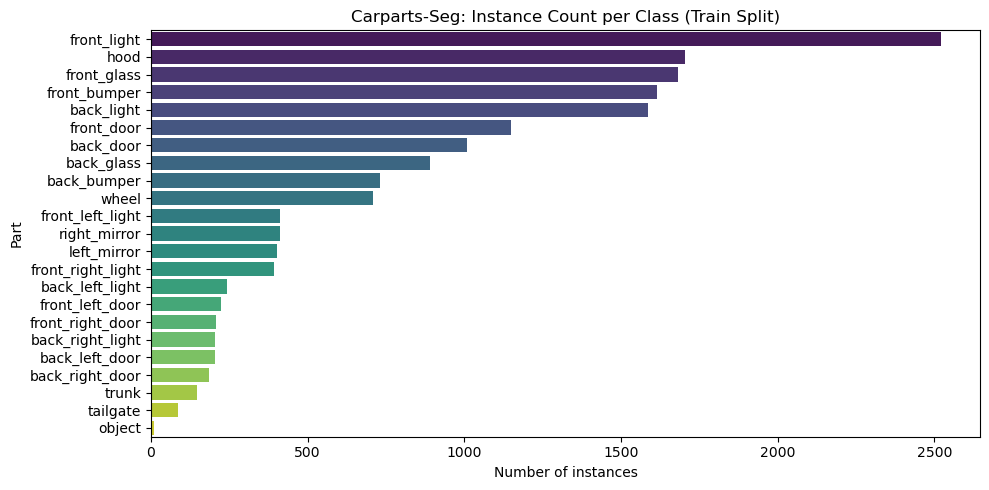

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=counts_df, x="instances", y="part", palette="viridis")
plt.title("Carparts-Seg: Instance Count per Class (Train Split)")
plt.xlabel("Number of instances")
plt.ylabel("Part")
plt.tight_layout()
plt.show()

### Sample annotated images (train split)

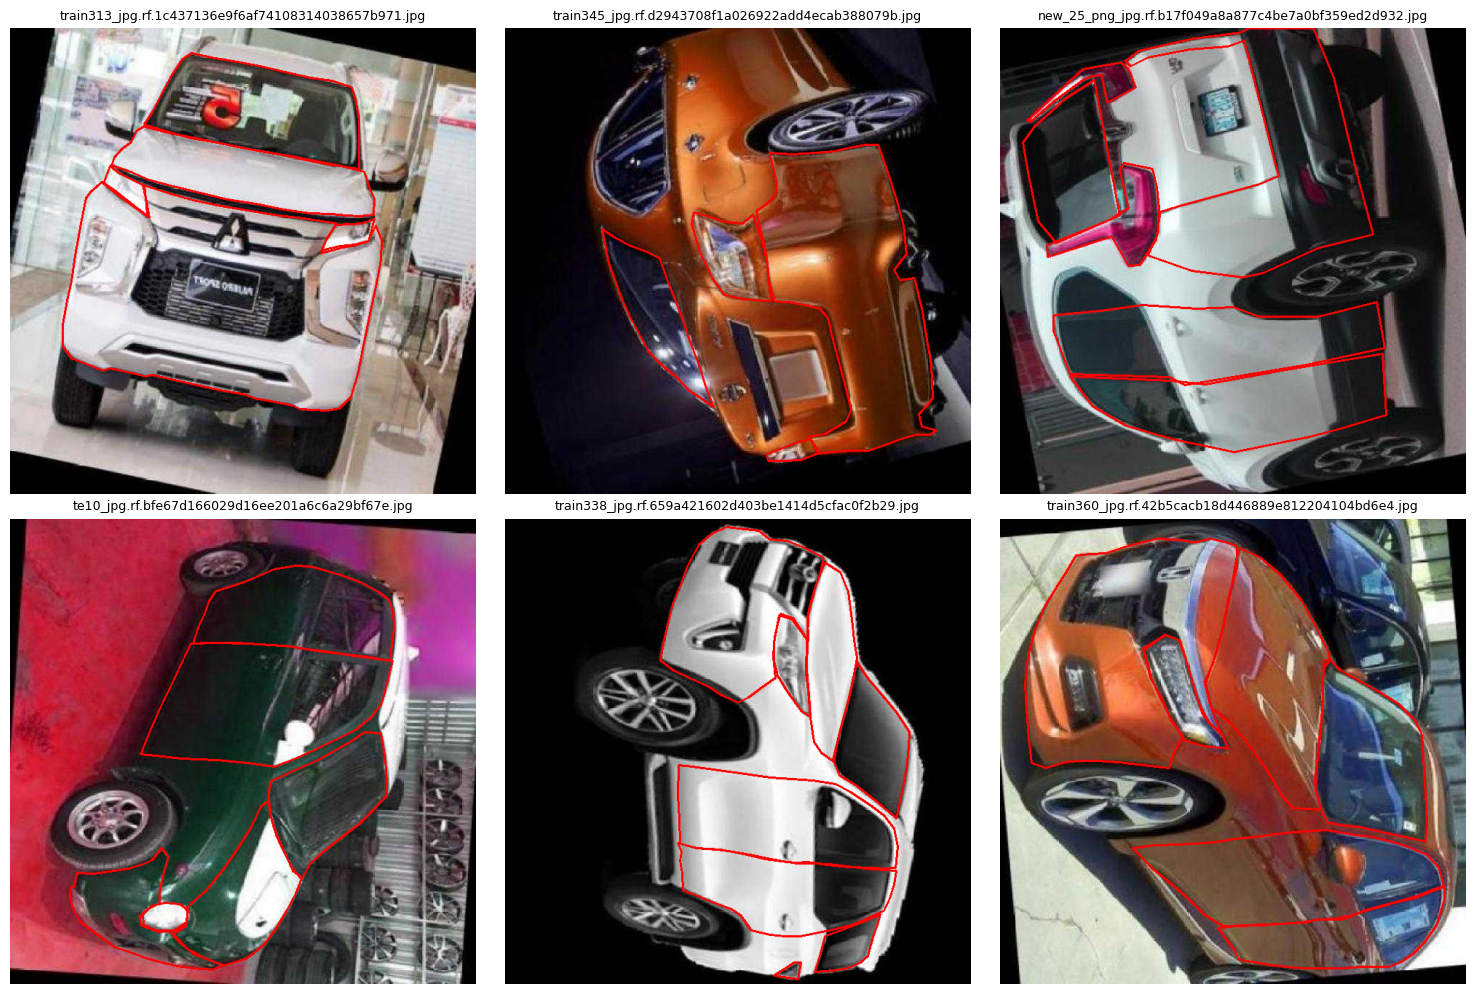

In [8]:
def show_sample_grid(split_key="train", n=6, seed=42):
    random.seed(seed)
    img_dir = Path(dataset_info[split_key])
    img_paths = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))

    if not img_paths:
        print(f"No images found for split \'{split_key}\' at {img_dir} -- skipping visualization.")
        return

    sample = random.sample(img_paths, min(n, len(img_paths)))

    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, img_path in zip(axes, sample):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = label_path_for_image(img_path)
        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.split()
                    if len(parts) < 3:
                        continue
                    coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    pts = coords.astype(np.int32)
                    cv2.polylines(img, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_grid("train", n=6)

## 4. Model and Paths

Explicit, stable paths derived from `PROJECT` / `RUN_NAME`. These are the single source of truth
used by every later section -- nothing below re-derives or overwrites them.

In [9]:
RUN_DIR = Path(PROJECT) / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"
BEST_MODEL = WEIGHTS_DIR / "best.pt"
LAST_MODEL = WEIGHTS_DIR / "last.pt"

print("RUN_DIR:    ", RUN_DIR.resolve())
print("WEIGHTS_DIR:", WEIGHTS_DIR.resolve())
print("BEST_MODEL: ", BEST_MODEL.resolve())
print("LAST_MODEL: ", LAST_MODEL.resolve())
print()
print("RUN_DIR exists:   ", RUN_DIR.exists())
print("BEST_MODEL exists:", BEST_MODEL.exists())
print("LAST_MODEL exists:", LAST_MODEL.exists())


RUN_DIR:     /home/jovyan/runs/segment/carparts_yolo11
WEIGHTS_DIR: /home/jovyan/runs/segment/carparts_yolo11/weights
BEST_MODEL:  /home/jovyan/runs/segment/carparts_yolo11/weights/best.pt
LAST_MODEL:  /home/jovyan/runs/segment/carparts_yolo11/weights/last.pt

RUN_DIR exists:    True
BEST_MODEL exists: True
LAST_MODEL exists: True


## 5. Train / Resume / Load Existing Model

Three-way branch, checked in this order every time the notebook runs:

1. **`best.pt` exists** -> training already completed. Load it. Do **not** train again.
2. **No `best.pt`, but `last.pt` exists** -> a previous run was interrupted. Resume from `last.pt`.
3. **Neither exists** -> start a fresh training run.

`exist_ok=True` is passed to `model.train(...)` so a fresh run reuses `RUN_DIR` instead of creating
`carparts_yolo112`, `carparts_yolo113`, etc.

In [10]:
from pathlib import Path

print("RUN_DIR:", RUN_DIR)
print("RUN_DIR exists:", RUN_DIR.exists())

print("BEST_MODEL:", BEST_MODEL)
print("BEST_MODEL exists:", BEST_MODEL)

print("LAST_MODEL:", LAST_MODEL)
print("LAST_MODEL exists:", LAST_MODEL.exists())

if RUN_DIR.exists():
    print("\nExisting files:")
    for f in RUN_DIR.rglob("*"):
        print(f)

RUN_DIR: /home/jovyan/runs/segment/carparts_yolo11
RUN_DIR exists: True
BEST_MODEL: /home/jovyan/runs/segment/carparts_yolo11/weights/best.pt
BEST_MODEL exists: /home/jovyan/runs/segment/carparts_yolo11/weights/best.pt
LAST_MODEL: /home/jovyan/runs/segment/carparts_yolo11/weights/last.pt
LAST_MODEL exists: True

Existing files:
/home/jovyan/runs/segment/carparts_yolo11/weights
/home/jovyan/runs/segment/carparts_yolo11/weights/best.pt
/home/jovyan/runs/segment/carparts_yolo11/weights/last.pt


In [11]:
def train_or_load_model():
    """Safe train/resume/load logic.

    Priority:
      1) best.pt exists -> load it, never train.
      2) last.pt exists -> resume only if RESUME_IF_INTERRUPTED is True.
      3) neither exists -> start a new run only if TRAIN_IF_NEEDED is True.
    """
    RUN_DIR.mkdir(parents=True, exist_ok=True)

    if BEST_MODEL.exists():
        print("Completed model found. Skipping training.")
        print("Loading:", BEST_MODEL.resolve())
        return YOLO(str(BEST_MODEL)), False

    if LAST_MODEL.exists() and RESUME_IF_INTERRUPTED:
        print("No best.pt found, but last.pt exists.")
        print("Resuming interrupted training from:", LAST_MODEL.resolve())

        resume_model = YOLO(str(LAST_MODEL))
        resume_model.train(resume=True)

        if not BEST_MODEL.exists():
            raise FileNotFoundError(
                f"Training resumed but best.pt was not created at {BEST_MODEL.resolve()}. "
                "Inspect the Ultralytics training output for the actual error."
            )

        print("Resume completed.")
        print("Best model:", BEST_MODEL.resolve())
        return YOLO(str(BEST_MODEL)), True

    if not TRAIN_IF_NEEDED:
        raise FileNotFoundError(
            f"No trained model was found at {BEST_MODEL.resolve()} and TRAIN_IF_NEEDED=False. "
            "Set TRAIN_IF_NEEDED=True to start training."
        )

    print("No existing checkpoint found. Starting a new training run.")

    model = YOLO(MODEL_VARIANT)
    model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH,
        project=str(PROJECT),
        name=RUN_NAME,
        exist_ok=True,
        patience=20,
        optimizer="auto",
        seed=42,
        plots=True,
        device=DEVICE,
    )

    if not BEST_MODEL.exists():
        raise FileNotFoundError(
            f"Training finished but best.pt was not found at {BEST_MODEL.resolve()}. "
            "Inspect the training output for errors."
        )

    print("Training completed successfully.")
    print("Best model:", BEST_MODEL.resolve())
    return YOLO(str(BEST_MODEL)), True

model, trained_this_run = train_or_load_model()


Completed model found. Skipping training.
Loading: /home/jovyan/runs/segment/carparts_yolo11/weights/best.pt


In [12]:
from pathlib import Path
import shutil

# Actual path where YOLO saved the trained model
actual_run = Path("/home/jovyan/runs/segment/runs/segment/carparts_yolo11")

# Path expected by the notebook
expected_run = Path("/home/jovyan/runs/segment/carparts_yolo11")

actual_best = actual_run / "weights" / "best.pt"
expected_best = expected_run / "weights" / "best.pt"

print("Actual best:", actual_best)
print("Actual exists:", actual_best.exists())

print("Expected best:", expected_best)
print("Expected exists:", expected_best.exists())

if actual_best.exists():
    expected_run.mkdir(parents=True, exist_ok=True)

    # Copy weights
    expected_weights = expected_run / "weights"
    expected_weights.mkdir(parents=True, exist_ok=True)

    shutil.copy2(
        actual_best,
        expected_best
    )

    # Also copy last.pt if available
    actual_last = actual_run / "weights" / "last.pt"
    if actual_last.exists():
        shutil.copy2(actual_last, expected_weights / "last.pt")

    print("\n✅ best.pt copied successfully!")
else:
    print("\n❌ Actual best.pt was not found.")

Actual best: /home/jovyan/runs/segment/runs/segment/carparts_yolo11/weights/best.pt
Actual exists: True
Expected best: /home/jovyan/runs/segment/carparts_yolo11/weights/best.pt
Expected exists: True

✅ best.pt copied successfully!


In [13]:
from pathlib import Path

best = Path("/home/jovyan/runs/segment/carparts_yolo11/weights/best.pt")

print("Best model:", best)
print("Exists:", best.exists())

if best.exists():
    print("✅ best.pt is ready!")
    print("Size:", round(best.stat().st_size / (1024**2), 2), "MB")
else:
    print("❌ best.pt still not found")

Best model: /home/jovyan/runs/segment/carparts_yolo11/weights/best.pt
Exists: True
✅ best.pt is ready!
Size: 5.74 MB


## 6. Training Results

Displays `results.png` if it exists. Falls back to `results.csv` if the plot isn't available.
Never crashes just because a visualization file is missing (e.g. when a completed model was
loaded directly and no training happened in this session).

In [14]:
def show_training_results():
    if not RUN_DIR.exists():
        print(f"Run directory not found: {RUN_DIR.resolve()}")
        print("This is normal only if no training run has been created yet.")
        return

    results_png = RUN_DIR / "results.png"
    results_csv = RUN_DIR / "results.csv"

    if results_png.exists():
        print("Displaying:", results_png.resolve())
        display(IPImage(filename=str(results_png)))
        return

    if results_csv.exists():
        print(f"{results_png.name} is not available.")
        print(f"Reading logged metrics from: {results_csv.resolve()}")
        df = pd.read_csv(results_csv)
        df.columns = [c.strip() for c in df.columns]
        display(df.tail())
        return

    print(f"No results.png or results.csv found in {RUN_DIR.resolve()}.")
    print("The trained model can still be used if best.pt exists.")

show_training_results()


No results.png or results.csv found in /home/jovyan/runs/segment/carparts_yolo11.
The trained model can still be used if best.pt exists.


## 7. Validation

Runs validation with the trained/loaded model and reports the standard Ultralytics
segmentation metrics (no invented metrics).

In [15]:
def validate_model(model):
    metrics = model.val(data=DATA_YAML, imgsz=IMG_SIZE, split="val")

    print("Box mAP50:      ", metrics.box.map50)
    print("Box mAP50-95:   ", metrics.box.map)
    print("Mask mAP50:     ", metrics.seg.map50)
    print("Mask mAP50-95:  ", metrics.seg.map)
    print("Precision (box):", metrics.box.mp)
    print("Recall (box):   ", metrics.box.mr)

    return metrics

val_metrics = validate_model(model)

Ultralytics 8.4.128 🚀 Python-3.12.13 torch-2.11.0+cu126 CUDA:0 (NVIDIA A16, 14962MiB)
YOLO11n-seg summary (fused): 114 layers, 2,839,053 parameters, 0 gradients, 9.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1131.8±280.0 MB/s, size: 36.0 KB)
val: Scanning /home/jovyan/datasets/carparts-seg/labels/val.cache... 401 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 80.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.1it/s 6.4s0.2s
                   all        401       2042       0.61      0.837      0.698      0.577      0.617      0.844      0.709      0.565
           back_bumper         94         94      0.872      0.939      0.928      0.762      0.881      0.949      0.934      0.733
             back_door        158        159      0.794      0.922      0.929      0.807      0.797      0.918      0.929      0.799
            back_gla

In [16]:
per_class = pd.DataFrame({
    "class": [names[i] for i in range(num_classes)],
    "mask_mAP50": val_metrics.seg.ap50,
    "mask_mAP50-95": val_metrics.seg.ap,
})
per_class.sort_values("mask_mAP50-95", ascending=False)

,class,mask_mAP50,mask_mAP50-95
10,front_glass,0.960729,0.890196
8,front_bumper,0.967810,0.882956
16,hood,0.960854,0.868547
9,front_door,0.920348,0.809703
1,back_door,0.928587,0.799122
2,back_glass,0.962489,0.791575
0,back_bumper,0.934100,0.733147
20,tailgate,0.853333,0.702549
13,front_light,0.906028,0.661184
5,back_light,0.880534,0.635608


In [17]:
def show_optional_training_plots():
    files = [
        ("confusion_matrix_normalized.png", "Confusion Matrix (Normalized)"),
        ("MaskPR_curve.png", "Mask Precision-Recall Curve"),
    ]

    found = False
    for filename, title in files:
        path = RUN_DIR / filename
        if path.exists():
            found = True
            plt.figure(figsize=(10, 6))
            plt.imshow(plt.imread(path))
            plt.title(title)
            plt.axis("off")
            plt.tight_layout()
            plt.show()
        else:
            print(f"Optional plot not found: {path}")

    if not found:
        print("No optional training plots are available in this run.")

show_optional_training_plots()


Optional plot not found: /home/jovyan/runs/segment/carparts_yolo11/confusion_matrix_normalized.png
Optional plot not found: /home/jovyan/runs/segment/carparts_yolo11/MaskPR_curve.png
No optional training plots are available in this run.


## 8. Sample Predictions and Segmentation Visualization

Runs inference on a handful of test (or val, if no test split exists) images and visualizes the
predicted masks, class names, and confidence scores. Robust to having fewer images than requested.


0: 640x640 1 back_door, 1 front_door, 6.4ms
1: 640x640 1 front_bumper, 1 front_glass, 1 front_left_light, 1 front_right_door, 1 front_right_light, 1 hood, 4 wheels, 6.4ms
2: 640x640 1 back_door, 1 back_glass, 1 back_light, 1 front_bumper, 1 front_door, 1 front_glass, 2 front_lights, 1 hood, 6.4ms
3: 640x640 1 back_bumper, 1 back_glass, 2 back_lights, 6.4ms
4: 640x640 1 back_light, 1 front_door, 1 front_light, 1 trunk, 6.4ms
5: 640x640 1 back_door, 1 front_bumper, 1 front_door, 1 front_glass, 1 front_light, 1 hood, 6.4ms
Speed: 1.6ms preprocess, 6.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/jovyan/runs/segment/predictions/carparts_yolo11
Predictions saved to: /home/jovyan/runs/segment/predictions/carparts_yolo11


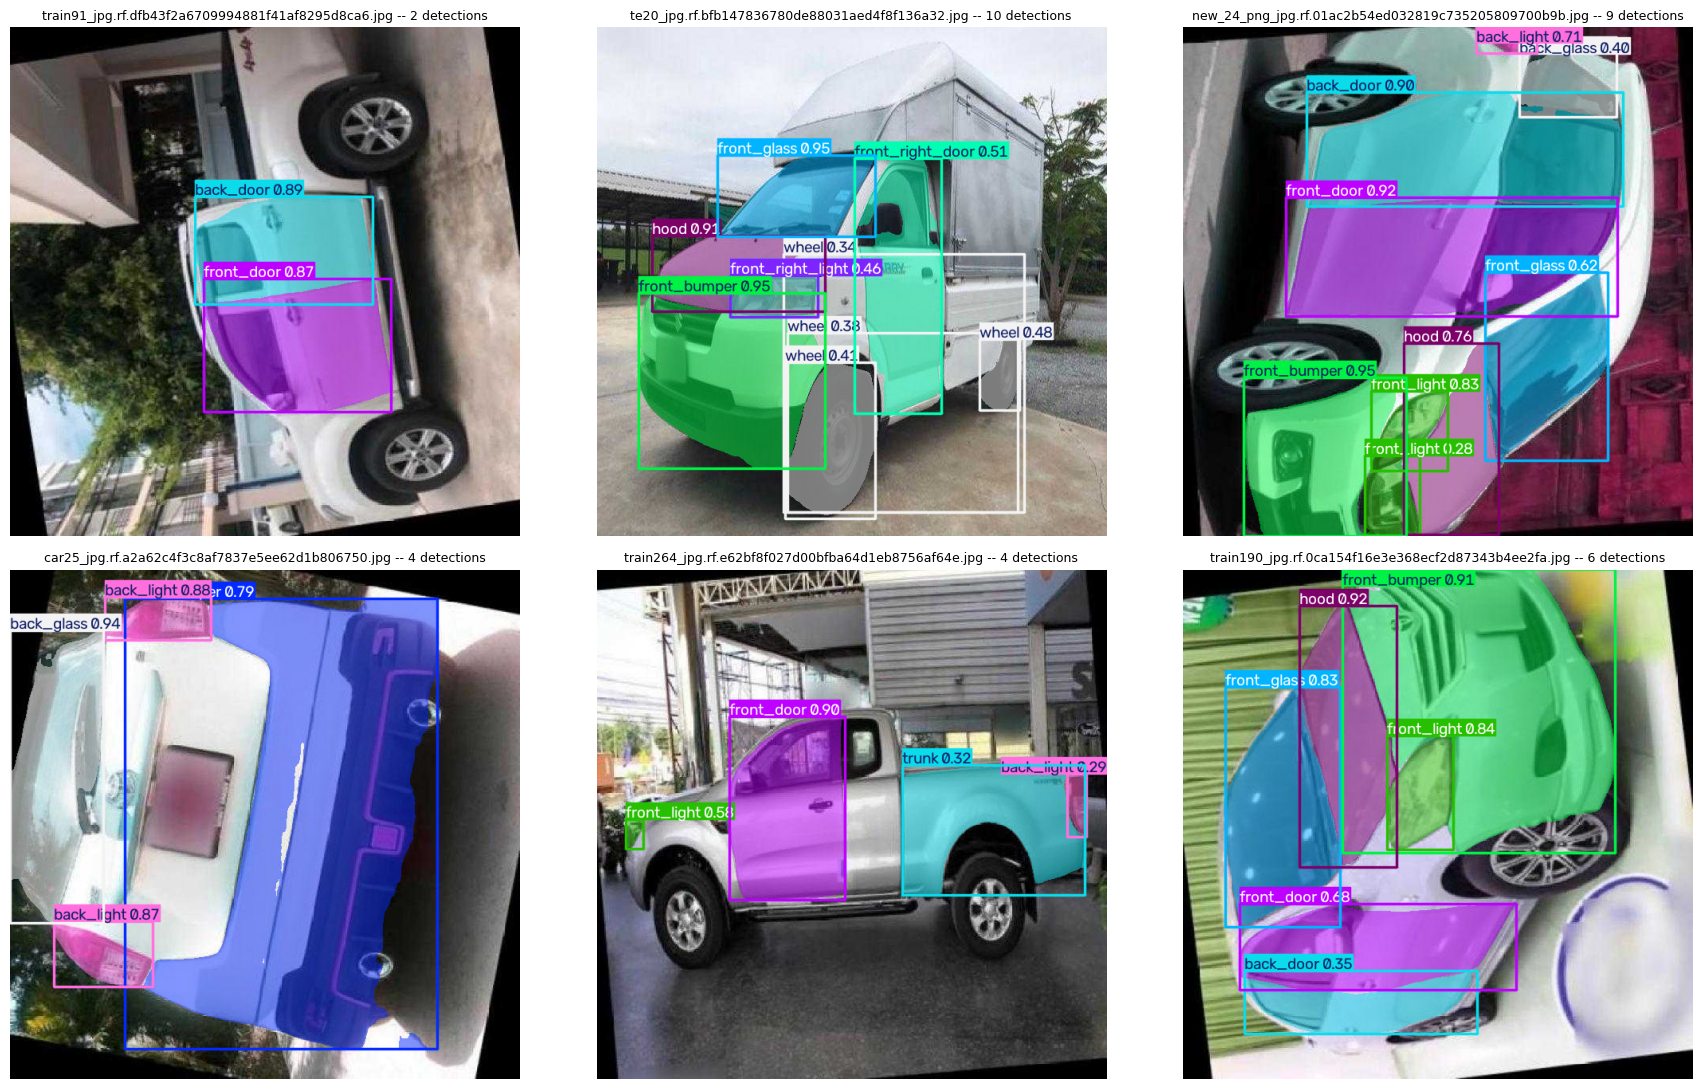

In [18]:
def visualize_predictions(model, n=6, conf=0.25):
    test_key = "test" if "test" in dataset_info else "val"
    test_dir = Path(dataset_info[test_key])
    test_images = []

    for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
        test_images.extend(test_dir.glob(ext))

    if not test_images:
        print(f"No images found in '{test_key}' split at {test_dir}.")
        return [], []

    sample_images = random.sample(test_images, min(n, len(test_images)))

    prediction_project = Path(PROJECT) / "predictions"
    prediction_project.mkdir(parents=True, exist_ok=True)

    pred_results = model.predict(
        source=[str(p) for p in sample_images],
        imgsz=IMG_SIZE,
        conf=conf,
        save=True,
        project=str(prediction_project),
        name=RUN_NAME,
        exist_ok=True,
        device=DEVICE,
    )

    prediction_dir = prediction_project / RUN_NAME
    print("Predictions saved to:", prediction_dir.resolve())

    n_results = len(pred_results)
    cols = min(3, n_results)
    rows = (n_results + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5.5 * rows))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, r in zip(axes, pred_results):
        im = r.plot()
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        ax.imshow(im)
        ax.axis("off")
        n_det = len(r.boxes) if r.boxes is not None else 0
        ax.set_title(f"{Path(r.path).name} -- {n_det} detections", fontsize=9)

    for ax in axes[n_results:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return pred_results, sample_images

pred_results, sample_test_images = visualize_predictions(model, n=6)


In [19]:
# Single-image inference example
if sample_test_images:
    single_result = model.predict(source=sample_test_images[0], imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]

    if single_result.boxes is not None and len(single_result.boxes) > 0:
        for cls_id, conf in zip(
            single_result.boxes.cls.cpu().numpy().astype(int),
            single_result.boxes.conf.cpu().numpy(),
        ):
            print(f"{names[cls_id]:15s} confidence={conf:.2f}")
    else:
        print("No detections above the confidence threshold for this image.")
else:
    print("No sample test images available -- skipping single-image inference example.")

back_door       confidence=0.89
front_door      confidence=0.87


## 9. Final Model Path / Export

Copies the best checkpoint to a stable output location for downstream use, only if it isn't
already there -- re-running this cell will not re-copy or retrain.

In [20]:
OUTPUT_DIR = Path("outputs") / "vehicle_part_segmentation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_model_path = OUTPUT_DIR / "best.pt"

if not BEST_MODEL.exists():
    raise FileNotFoundError(
        f"Cannot export because the trained checkpoint does not exist: {BEST_MODEL.resolve()}"
    )

if final_model_path.exists():
    print(f"Final model already exists at: {final_model_path.resolve()}")
    print("Not overwriting it.")
else:
    shutil.copy2(BEST_MODEL, final_model_path)
    print(f"Copied best checkpoint to: {final_model_path.resolve()}")

print(f"File size: {final_model_path.stat().st_size / 1e6:.2f} MB")


Final model already exists at: /home/jovyan/outputs/vehicle_part_segmentation/best.pt
Not overwriting it.
File size: 6.01 MB


In [21]:
# Quick reload sanity check -- confirms the exported weights load and run inference correctly
reloaded = YOLO(str(final_model_path))
if sample_test_images:
    sanity_result = reloaded.predict(source=sample_test_images[0], imgsz=IMG_SIZE, conf=0.25, verbose=False)
    n_det = len(sanity_result[0].boxes) if sanity_result[0].boxes is not None else 0
    print("Reload OK -- detections on sanity image:", n_det)
else:
    print("Reload OK -- no sample test image was available to run a sanity prediction on.")

print()
print("Vehicle Part Segmentation model ready.")
print(f"Best model: {final_model_path.resolve()}")

Reload OK -- detections on sanity image: 2

Vehicle Part Segmentation model ready.
Best model: /home/jovyan/outputs/vehicle_part_segmentation/best.pt


## 10. Structured Part-Instance Output (for Damage-to-Part integration)

This section adds **no new model, no new dataset, and no retraining**. It only repackages what
`model.predict(...)` already returns into a clean, consistent structure that a separate
Damage-to-Part association notebook can consume.

Design notes (see audit for details):
- `result.boxes.xyxy` is already in **original-image pixel coordinates** (Ultralytics rescales
  internally from the inference resolution back to `result.orig_shape`).
- `result.masks.xy` is the **polygon in original-image coordinates** (as opposed to
  `result.masks.data`, which is a low-resolution prototype mask in *model* space and is
  intentionally **not** used here).
- Class names are read from `result.names` (the model's own mapping) rather than the
  module-level `names` dict, so this stays correct even if this cell is ever reused with a
  different checkpoint.
- Every detected instance is preserved 1:1 -- there is no de-duplication, no "keep the largest",
  and no per-class collapsing. Multiple instances of the same part (e.g. 4 wheels) each get their
  own entry.


In [22]:
from typing import List, Dict, Any


def extract_part_instances(result) -> List[Dict[str, Any]]:
    """Convert a single Ultralytics YOLOv11-seg `Results` object into a list of
    structured, JSON-serializable part-instance dicts.

    Every instance in `result` is preserved as-is. Nothing is filtered, ranked,
    merged, or matched to anything else here -- that is out of scope for this
    notebook (see Phase 7 / Phase 9 discussion above).
    """
    img_h, img_w = result.orig_shape  # original image size, NOT the inference size

    boxes = result.boxes
    masks = result.masks

    if boxes is None or len(boxes) == 0:
        return []

    cls_ids = boxes.cls.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy()
    xyxy = boxes.xyxy.cpu().numpy()  # original-image coordinates

    # masks.xy: one (N,2) polygon array per instance, already rescaled to the
    # original image. If a model/version ever returns no masks for a given
    # result (e.g. box-only fallback), fall back to empty polygons rather than
    # crashing, and flag it via mask_area = 0.0 so diagnostics can catch it.
    if masks is not None:
        polygons = masks.xy
    else:
        polygons = [None] * len(cls_ids)

    class_names = result.names  # model's own id -> name mapping

    instances = []
    for i in range(len(cls_ids)):
        cls_id = int(cls_ids[i])
        conf = float(confs[i])
        x1, y1, x2, y2 = [float(v) for v in xyxy[i]]

        poly = polygons[i] if polygons is not None else None
        if poly is not None and len(poly) >= 3:
            poly_list = poly.astype(float).tolist()
            mask_area = float(cv2.contourArea(poly.astype(np.float32)))
        else:
            poly_list = []
            mask_area = 0.0

        instances.append({
            "part_id": i,                                   # index within this image
            "part_class_id": cls_id,
            "part": class_names.get(cls_id, f"unknown_{cls_id}"),
            "part_confidence": conf,
            "part_bbox": [x1, y1, x2, y2],                   # original-image coords
            "mask_polygon": poly_list,                       # original-image coords
            "mask_area": mask_area,
            "image_width": int(img_w),
            "image_height": int(img_h),
        })

    return instances


## 11. Validation / Debugging Diagnostics

Runs the structured extraction on a handful of sample images and checks, per instance:

1. bbox lies within image boundaries and is non-degenerate (`x1<x2`, `y1<y2`)
2. mask has non-zero area
3. polygon coordinates fall within image boundaries
4. class_id is a known class
5. confidence is in `[0, 1]`

Any inconsistency is printed explicitly rather than silently ignored.


In [23]:
def run_diagnostics(model, image_paths, conf=0.25):
    """Run inference + structured extraction on a list of images and print a
    full per-instance diagnostic report. Returns the raw reports for reuse
    (e.g. by the visualization cell below) so inference is not repeated.
    """
    image_paths = [str(p) for p in image_paths]
    results = model.predict(source=image_paths, imgsz=IMG_SIZE, conf=conf,
                             device=DEVICE, verbose=False)

    reports = []
    for img_path, r in zip(image_paths, results):
        h, w = r.orig_shape
        print("=" * 78)
        print(f"IMAGE: {Path(img_path).name}")
        print(f"IMAGE SIZE: {w} x {h}")

        instances = extract_part_instances(r)
        print(f"PART DETECTIONS: {len(instances)}")

        issues = []
        for inst in instances:
            print(f"\n  Instance {inst['part_id']}:")
            print(f"    class_id:   {inst['part_class_id']}")
            print(f"    class_name: {inst['part']}")
            print(f"    confidence: {inst['part_confidence']:.4f}")
            print(f"    bbox:       {[round(v, 1) for v in inst['part_bbox']]}")
            print(f"    mask_area:  {inst['mask_area']:.1f}")

            x1, y1, x2, y2 = inst["part_bbox"]
            if not (0 <= x1 < x2 <= w and 0 <= y1 < y2 <= h):
                issues.append(
                    f"Instance {inst['part_id']}: bbox {inst['part_bbox']} "
                    f"is out of bounds or degenerate for image {w}x{h}"
                )
            if inst["mask_area"] <= 0:
                issues.append(f"Instance {inst['part_id']}: mask area is zero (no polygon returned)")
            if inst["mask_polygon"]:
                poly = np.array(inst["mask_polygon"])
                if (poly[:, 0].min() < -1 or poly[:, 0].max() > w + 1 or
                        poly[:, 1].min() < -1 or poly[:, 1].max() > h + 1):
                    issues.append(f"Instance {inst['part_id']}: polygon coordinates fall outside image bounds")
            if inst["part_class_id"] not in names:
                issues.append(f"Instance {inst['part_id']}: class_id {inst['part_class_id']} is not a known class")
            if not (0.0 <= inst["part_confidence"] <= 1.0):
                issues.append(f"Instance {inst['part_id']}: confidence {inst['part_confidence']} outside [0, 1]")

        if issues:
            print("\n  INCONSISTENCIES FOUND:")
            for msg in issues:
                print("   -", msg)
        else:
            print("\n  All automated checks passed for this image.")

        reports.append({"image_path": img_path, "instances": instances, "issues": issues})

    total_issues = sum(len(r["issues"]) for r in reports)
    print("\n" + "=" * 78)
    print(f"DIAGNOSTIC SUMMARY: {len(reports)} images checked, {total_issues} inconsistencies found.")
    return reports


_diag_key = "test" if "test" in dataset_info else "val"
_diag_dir = Path(dataset_info[_diag_key])
_diag_images = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    _diag_images.extend(_diag_dir.glob(ext))

random.seed(7)
_diag_sample = random.sample(_diag_images, min(6, len(_diag_images)))

diagnostic_reports = run_diagnostics(model, _diag_sample, conf=0.25)


IMAGE: train173_jpg.rf.91a12f502bb2122957caeb84144555b4.jpg
IMAGE SIZE: 640 x 640
PART DETECTIONS: 6

  Instance 0:
    class_id:   16
    class_name: hood
    confidence: 0.9451
    bbox:       [339.6, 203.5, 506.7, 270.0]
    mask_area:  6990.0

  Instance 1:
    class_id:   10
    class_name: front_glass
    confidence: 0.9391
    bbox:       [298.2, 116.3, 416.1, 208.0]
    mask_area:  6416.5

  Instance 2:
    class_id:   9
    class_name: front_door
    confidence: 0.8657
    bbox:       [238.6, 117.1, 320.7, 444.9]
    mask_area:  22610.0

  Instance 3:
    class_id:   13
    class_name: front_light
    confidence: 0.8231
    bbox:       [398.7, 264.7, 457.5, 322.6]
    mask_area:  2529.0

  Instance 4:
    class_id:   8
    class_name: front_bumper
    confidence: 0.7631
    bbox:       [379.7, 262.3, 520.0, 481.8]
    mask_area:  21506.0

  Instance 5:
    class_id:   1
    class_name: back_door
    confidence: 0.6625
    bbox:       [205.5, 117.8, 256.7, 436.0]
    mask_area:

## 12. Visual Debugging: Mask-to-Part Correspondence

Overlays, for each sample image: the segmentation masks (colored by class), the class name,
confidence, and bounding box. Use this to manually confirm that a mask labeled "front_door" is
actually drawn over a door, that a "bumper" mask is actually over a bumper, etc. -- numeric
mAP alone does not tell you this; a class with high mAP can still occasionally localize well but
mislabel, and a class with mediocre mAP might still be visually obviously correct or wrong in a
way that matters for this specific project.

Instances are colored **by class**, not by instance, so that repeated parts (e.g. all wheels)
share a color and are easy to compare across the image.


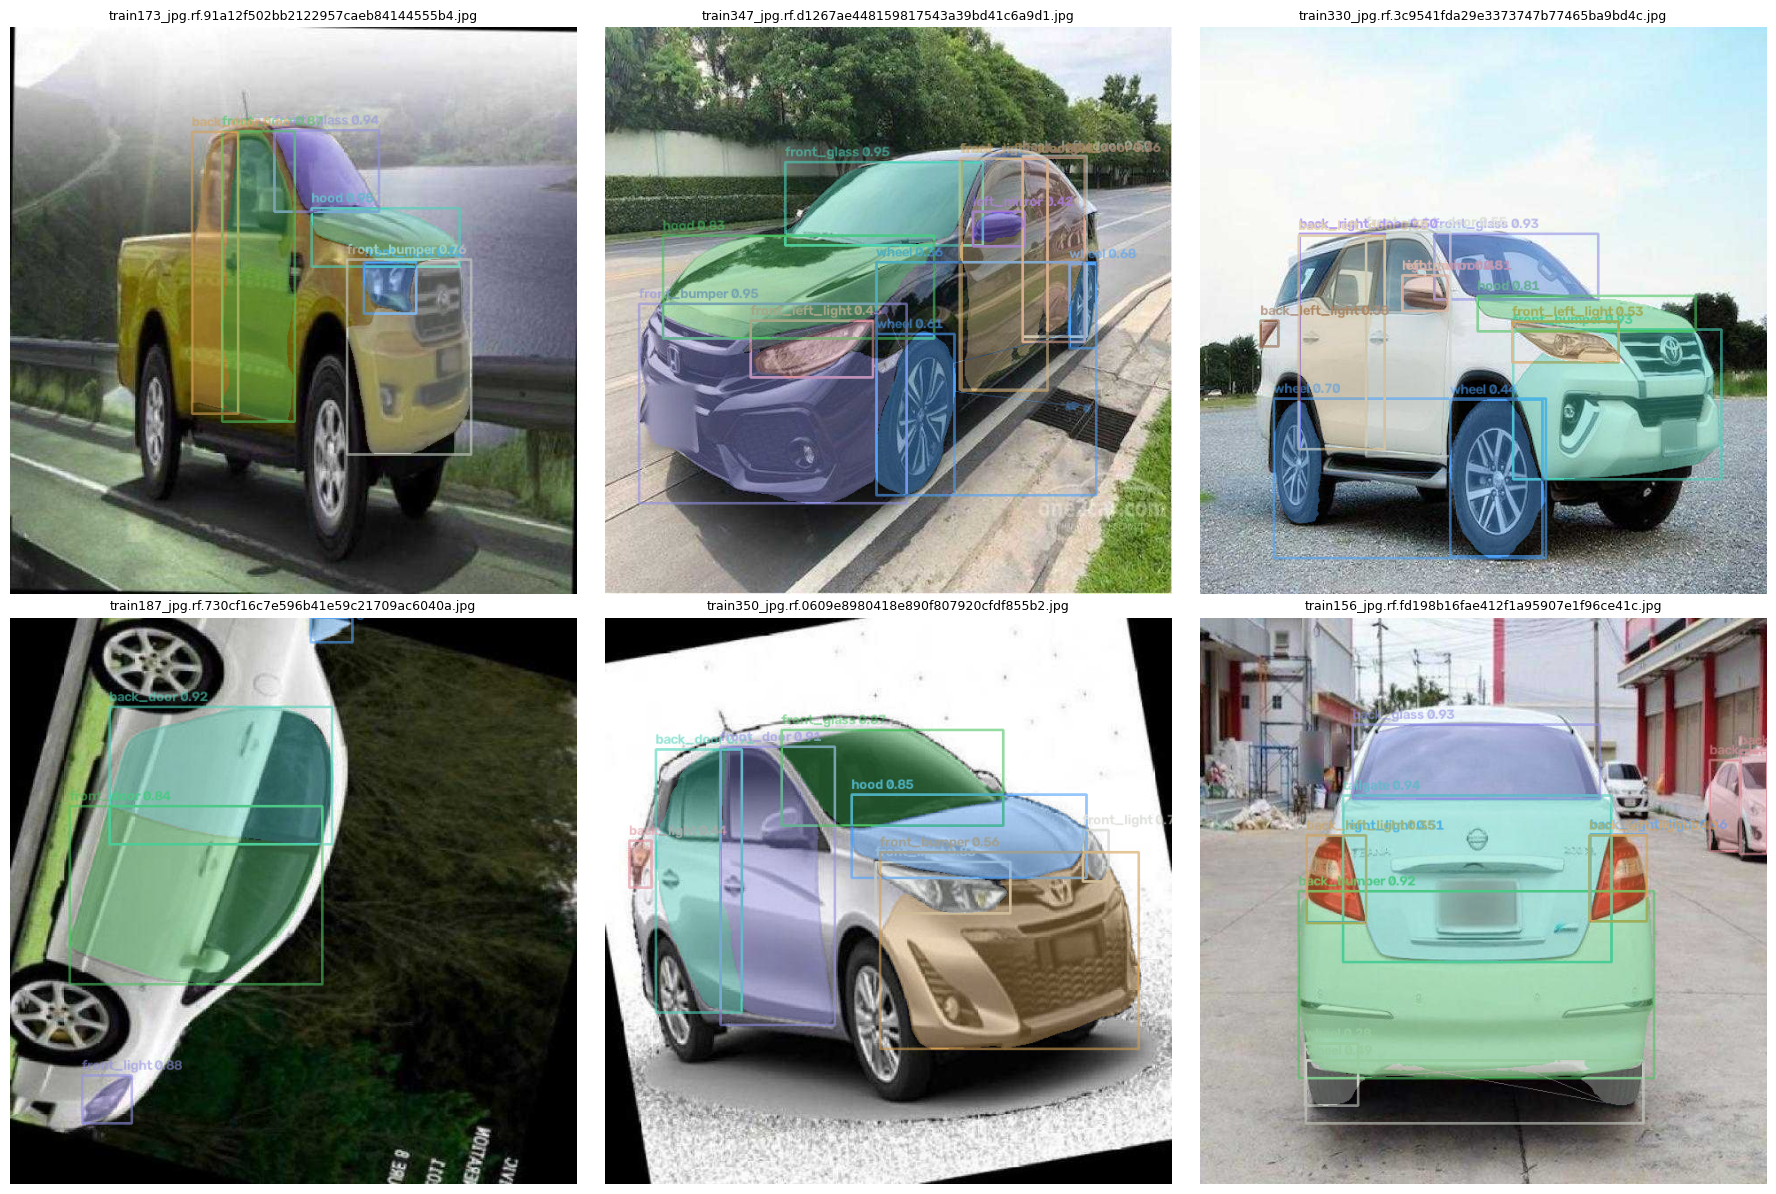

Manually verify above: does each colored mask actually sit on the named part
(door mask on a door, bumper mask on a bumper, wheel mask on a wheel, etc.)?


In [24]:
def visualize_part_instances(image_path, instances, ax=None):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img.copy()

    rng = np.random.default_rng(42)
    color_by_class = {}

    def get_color(cls_id):
        if cls_id not in color_by_class:
            color_by_class[cls_id] = tuple(int(c) for c in rng.integers(60, 255, size=3))
        return color_by_class[cls_id]

    for inst in instances:
        color = get_color(inst["part_class_id"])

        if inst["mask_polygon"]:
            pts = np.array(inst["mask_polygon"], dtype=np.int32)
            cv2.fillPoly(overlay, [pts], color)

        x1, y1, x2, y2 = [int(round(v)) for v in inst["part_bbox"]]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{inst['part']} {inst['part_confidence']:.2f}"
        cv2.putText(img, label, (x1, max(y1 - 6, 0)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, color, 2, cv2.LINE_AA)

    blended = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)

    if ax is None:
        plt.figure(figsize=(8, 8))
        plt.imshow(blended)
        plt.axis("off")
        plt.title(Path(image_path).name)
        plt.show()
    else:
        ax.imshow(blended)
        ax.axis("off")
        ax.set_title(Path(image_path).name, fontsize=9)


n_show = len(diagnostic_reports)
cols = min(3, n_show) if n_show else 1
rows = (n_show + cols - 1) // cols if n_show else 1
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
axes = np.atleast_1d(axes).reshape(-1)

for ax, report in zip(axes, diagnostic_reports):
    visualize_part_instances(report["image_path"], report["instances"], ax=ax)

for ax in axes[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Manually verify above: does each colored mask actually sit on the named part")
print("(door mask on a door, bumper mask on a bumper, wheel mask on a wheel, etc.)?")


## 13. Output Contract for the Damage-to-Part Integration Notebook

This notebook's responsibility ends here: **image -> vehicle part segmentation -> clean structured
part instances.** It does **not** decide which part is damaged -- that is a separate inference step
performed by a different notebook, using both this model's output and the Damage Detection model's
output.

For a given image, the integration notebook should consume the list returned by
`extract_part_instances(result)` for that image, i.e. a list of:

```python
{
    "part_id": int,            # index of this instance within the image
    "part_class_id": int,      # 0-22, Carparts-Seg class id
    "part": str,                # class name, e.g. "front_door", "wheel"
    "part_confidence": float,   # 0-1, from the segmentation model
    "part_bbox": [x1, y1, x2, y2],   # ORIGINAL image pixel coordinates
    "mask_polygon": [[x, y], ...],   # ORIGINAL image pixel coordinates
    "mask_area": float,         # pixel area of the polygon
    "image_width": int,
    "image_height": int,
}
```

alongside the Damage Detection model's own output (`damage_type`, `damage_bbox`,
`damage_confidence`) for the same image, and combine them using multiple spatial features
(damage-in-part ratio, true IoU, center proximity, part confidence, bbox containment, candidate
ranking, ambiguity margin) as described in the project's association design -- **not** a single
largest-overlap rule, and **not** implemented in this notebook.

**Known limitation to carry forward, not silently paper over:** the Carparts-Seg taxonomy contains
both generic and side-specific labels for the same physical part (e.g. `front_door` *and*
`front_left_door` / `front_right_door`; `back_light` *and* `back_left_light` / `back_right_light`).
The same physical part can legitimately come back under either label depending on the image, and
the side-specific subclasses have measurably weaker validation AP (see audit). The association
notebook should be aware that `"part"` values are not a fully disjoint, side-normalized taxonomy --
this notebook exposes the raw class name and does not invent a canonical mapping that the dataset
itself does not define.


In [25]:
print("Number of classes:", len(model.names))
print("Classes:")
for class_id, class_name in model.names.items():
    print(class_id, "->", class_name)

Number of classes: 23
Classes:
0 -> back_bumper
1 -> back_door
2 -> back_glass
3 -> back_left_door
4 -> back_left_light
5 -> back_light
6 -> back_right_door
7 -> back_right_light
8 -> front_bumper
9 -> front_door
10 -> front_glass
11 -> front_left_door
12 -> front_left_light
13 -> front_light
14 -> front_right_door
15 -> front_right_light
16 -> hood
17 -> left_mirror
18 -> object
19 -> right_mirror
20 -> tailgate
21 -> trunk
22 -> wheel


In [27]:
from PIL import Image
import numpy as np

IMAGE_PATH = r"runs/segment/predictions/carparts_yolo11/train91_jpg.rf.dfb43f2a6709994881f41af8295d8ca6.jpg"

# Load image
image = np.array(Image.open(IMAGE_PATH).convert("RGB"))

# Run segmentation
results = model(image)
result = results[0]

print("Image shape:", image.shape)

print("\nBoxes:")
print(result.boxes)

print("\nMasks:")
print(result.masks)

if result.masks is not None:
    print("\nMask coordinates:")

    for i, polygon in enumerate(result.masks.xy):
        print(
            f"Mask {i}: "
            f"min_x={polygon[:,0].min():.1f}, "
            f"max_x={polygon[:,0].max():.1f}, "
            f"min_y={polygon[:,1].min():.1f}, "
            f"max_y={polygon[:,1].max():.1f}"
        )


0: 640x640 2 front_doors, 1 front_light, 19.2ms
Speed: 2.1ms preprocess, 19.2ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)
Image shape: (640, 640, 3)

Boxes:
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 9., 13.,  9.], device='cuda:0')
conf: tensor([0.7482, 0.5299, 0.2836], device='cuda:0')
data: tensor([[2.4248e+02, 3.2536e+02, 4.7644e+02, 4.8225e+02, 7.4821e-01, 9.0000e+00],
        [3.9105e+02, 6.0009e+02, 4.3350e+02, 6.2187e+02, 5.2991e-01, 1.3000e+01],
        [2.3767e+02, 2.1560e+02, 4.5662e+02, 3.2671e+02, 2.8361e-01, 9.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([3, 6])
xywh: tensor([[359.4630, 403.8018, 233.9605, 156.8926],
        [412.2710, 610.9795,  42.4482,  21.7744],
        [347.1431, 271.1542, 218.9526, 111.1096]], device='cuda:0')
xywhn: tensor([[0.5617, 0.6309, 0.3656, 0.2451],
        [0.6442, 0.9547, 0.0663, 0.0340],
        [0.5424, 0.4237, 0.3421, 0.1736]], device=

In [28]:
if result.masks is not None:

    for i in range(len(result.masks)):

        class_id = int(result.boxes.cls[i])
        confidence = float(result.boxes.conf[i])

        print(
            f"Instance {i}: "
            f"class_id={class_id}, "
            f"class={model.names[class_id]}, "
            f"confidence={confidence:.3f}"
        )

Instance 0: class_id=9, class=front_door, confidence=0.748
Instance 1: class_id=13, class=front_light, confidence=0.530
Instance 2: class_id=9, class=front_door, confidence=0.284


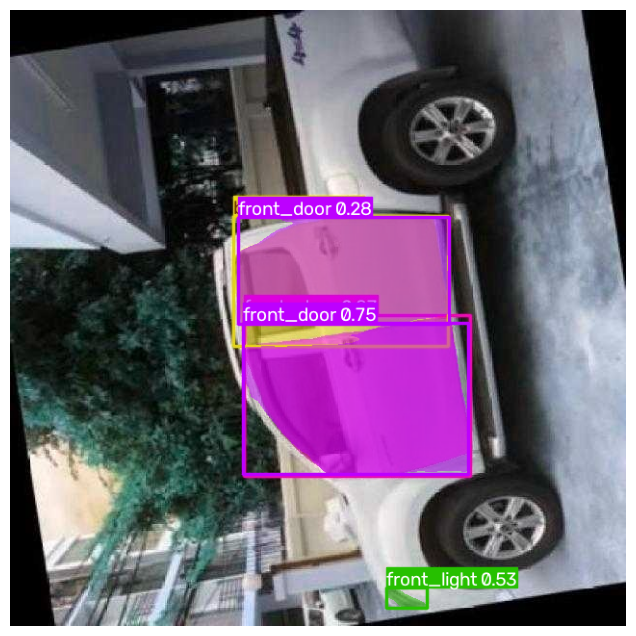

In [29]:
annotated = result.plot()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.show()

In [30]:
if result.boxes is not None:

    print(result.boxes.xyxy)

tensor([[242.4828, 325.3555, 476.4432, 482.2480],
        [391.0469, 600.0923, 433.4951, 621.8667],
        [237.6668, 215.5993, 456.6194, 326.7090]], device='cuda:0')


In [31]:
print("Image shape:", image.shape)

if result.masks is not None:
    for i, polygon in enumerate(result.masks.xy):
        print(
            f"Mask {i}: "
            f"min_x={polygon[:,0].min():.1f}, "
            f"max_x={polygon[:,0].max():.1f}, "
            f"min_y={polygon[:,1].min():.1f}, "
            f"max_y={polygon[:,1].max():.1f}"
        )

Image shape: (640, 640, 3)
Mask 0: min_x=243.0, max_x=476.0, min_y=326.0, max_y=482.0
Mask 1: min_x=392.0, max_x=431.0, min_y=601.0, max_y=621.0
Mask 2: min_x=238.0, max_x=456.0, min_y=216.0, max_y=326.0
